# Customer-Level Uplift Modeling

## Introduction

The previous notebooks answered two important questions:

1. Did the email campaigns improve outcomes?
2. Were the observed effects statistically reliable?

This notebook asks a more advanced business question:

> Which customers are most likely to benefit from receiving an email?

This is different from ordinary predictive modeling.

A normal conversion model predicts:

> Who is likely to purchase?

An uplift model predicts:

> Whose purchase probability changes because of treatment?

That distinction matters.

A customer who would purchase anyway may not need an email.

A customer who will never purchase may also not be worth targeting.

The most valuable customers are often those whose behavior changes because of the campaign.

## Workflow

Customer features  
→ Treatment assignment  
→ Separate treatment and control models  
→ Predict potential outcomes  
→ Estimate customer-level uplift  
→ Rank customers  
→ Evaluate targeting strategy  
→ Estimate business value

In [121]:
# Core data tools
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss

# Advanced tabular model
from lightgbm import LGBMClassifier

In [82]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:,.4f}".format)

In [83]:
# Load cleaned data
DATA_PATH = "../data/processed/hillstrom_cleaned.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.4400,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0000
1,6,3) $200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000
2,7,2) $100 - $200,180.6500,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0000
3,9,5) $500 - $750,675.8300,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0000
4,2,1) $0 - $100,45.3400,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0000


In [84]:
# Fix inconsistent zip-code category spelling
df["zip_code"] = df["zip_code"].replace({
    "Surburban": "Suburban"
})

In [85]:
df["zip_code"].value_counts()

zip_code
Suburban    28776
Urban       25661
Rural        9563
Name: count, dtype: int64

### Validate the data

In [86]:
# Check dataset structure
print("Dataset shape:", df.shape)
print("\nMissing values:", df.isna().sum().sum())
print("\nExperiment groups:")
print(df["segment"].value_counts())

Dataset shape: (64000, 12)

Missing values: 0

Experiment groups:
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64


## Feature Selection and Leakage Prevention

Uplift modeling requires special care with feature selection.

We may only use information that was available **before treatment assignment**.

Therefore, we must exclude:

- `segment` — this defines treatment assignment
- `visit` — this occurs after treatment
- `conversion` — this is the outcome
- `spend` — this occurs after treatment

Using post-treatment variables would create leakage and invalidate the customer targeting model.

The model will use only pre-treatment customer characteristics.

In [87]:
# Features available before treatment
feature_columns = [
    "recency",
    "history_segment",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel"
]

# Binary outcome
target_column = "conversion"

feature_columns

['recency',
 'history_segment',
 'history',
 'mens',
 'womens',
 'zip_code',
 'newbie',
 'channel']

Mens E-Mail
vs
No E-Mail

# Part 1: Mens E-Mail Uplift Model

We first estimate heterogeneous treatment effects for:

- Treatment: Mens E-Mail
- Control: No E-Mail

The Womens E-Mail group is temporarily excluded from this comparison.

This gives us a clean binary treatment problem.

In [88]:
# Keep only Mens E-Mail and No E-Mail groups
mens_df = df[
    df["segment"].isin([
        "Mens E-Mail",
        "No E-Mail"
    ])
].copy()

# Create binary treatment indicator
mens_df["treatment"] = (
    mens_df["segment"] == "Mens E-Mail"
).astype(int)

# Check treatment distribution
mens_df["treatment"].value_counts()

treatment
1    21307
0    21306
Name: count, dtype: int64

Build modeling dataset

In [89]:
# Customer features
X = mens_df[feature_columns].copy()

# Conversion outcome
y = mens_df[target_column].copy()

# Treatment assignment
treatment = mens_df["treatment"].copy()

print("X shape:", X.shape)
print("Outcome rate:", y.mean())
print("Treatment rate:", treatment.mean())

X shape: (42613, 8)
Outcome rate: 0.009128669654800178
Treatment rate: 0.5000117335085538


## Train/Test Split

In [93]:
# Combine treatment and outcome for stratification
stratify_key = (
    treatment.astype(str)
    + "_"
    + y.astype(str)
)

In [94]:
# Split customer indices
train_idx, test_idx = train_test_split(
    np.arange(len(X)),
    test_size=0.25,
    random_state=42,
    stratify=stratify_key
)


In [95]:
train_idx

array([21103, 21758,   364, ...,  5398, 26956, 35891], shape=(31959,))

In [96]:
# Create train data
X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()
treatment_train = treatment.iloc[train_idx].copy()

In [97]:
# Create test data
X_test = X.iloc[test_idx].copy()
y_test = y.iloc[test_idx].copy()
treatment_test = treatment.iloc[test_idx].copy()

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 31959
Test size: 10654


### Define feature Types

In [98]:
# Numerical features
numerical_features = [
    "recency",
    "history"
]

# Categorical features
categorical_features = [
    "history_segment",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel"
]

### Build the Preprocessing Pipeline

In [99]:
# Numerical preprocessing
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

## T-Learner Strategy

We use a T-Learner.

The idea is simple:

### Treatment model

Train a model using customers who received Mens E-Mail:

> P(conversion | customer features, treated)

### Control model

Train a separate model using customers who received No E-Mail:

> P(conversion | customer features, untreated)

For each customer:

> Predicted uplift = Predicted treatment probability - Predicted control probability

This gives an estimated customer-level treatment effect.

In [100]:
# Identify treated and control customers
treated_mask = treatment_train == 1
control_mask = treatment_train == 0

# Treatment training data
X_train_treated = X_train.loc[treated_mask]
y_train_treated = y_train.loc[treated_mask]

In [101]:
# Control training data
X_train_control = X_train.loc[control_mask]
y_train_control = y_train.loc[control_mask]

print("Treatment training rows:", len(X_train_treated))
print("Control training rows:", len(X_train_control))

Treatment training rows: 15980
Control training rows: 15979


#### Create treatment model

In [102]:
# Treatment model
treatment_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

#### Create control model

In [103]:
# Control model
control_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

#### Train treatment model

In [104]:
# Train treatment model
treatment_model.fit(
    X_train_treated,
    y_train_treated
)

print("Treatment model trained.")

Treatment model trained.


In [105]:
# Train control model
control_model.fit(
    X_train_control,
    y_train_control
)

print("Control model trained.")

Control model trained.


## Predicting Potential Outcomes

For every customer in the test set, we generate two predictions:

1. Estimated conversion probability if treated
2. Estimated conversion probability if untreated

We can never observe both outcomes for the same real customer.

This is the fundamental causal inference problem.

The model estimates the missing counterfactual outcome.

In [106]:
# Predicted conversion probability under treatment
p_treatment = treatment_model.predict_proba(
    X_test
)[:, 1]

# Predicted conversion probability under control
p_control = control_model.predict_proba(
    X_test
)[:, 1]

print("Treatment predictions:", p_treatment[:5])
print("Control predictions:", p_control[:5])

Treatment predictions: [0.00825216 0.02622366 0.00546782 0.02098724 0.02091468]
Control predictions: [0.00258342 0.00891068 0.00130376 0.01591689 0.02146499]


## Calculate Predicted Uplift

In [107]:
# Estimate customer-level uplift
predicted_uplift = (
    p_treatment
    - p_control
)

predicted_uplift[:10]

array([ 0.00566875,  0.01731298,  0.00416406,  0.00507034, -0.00055032,
        0.01475584,  0.01667015,  0.00370951,  0.00525981,  0.00479236])

In [108]:
# Create customer-level uplift results
uplift_results = X_test.copy()

uplift_results["actual_conversion"] = y_test.values
uplift_results["actual_treatment"] = treatment_test.values

uplift_results["p_conversion_treated"] = p_treatment
uplift_results["p_conversion_control"] = p_control

uplift_results["predicted_uplift"] = predicted_uplift

uplift_results.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,actual_conversion,actual_treatment,p_conversion_treated,p_conversion_control,predicted_uplift
39518,2,1) $0 - $100,33.4600,1,0,Suburban,1,Phone,0,1,0.0083,0.0026,0.0057
46286,8,4) $350 - $500,373.1700,1,1,Suburban,0,Web,0,0,0.0262,0.0089,0.0173
44136,9,2) $100 - $200,124.8100,0,1,Urban,1,Phone,0,1,0.0055,0.0013,0.0042
58561,2,4) $350 - $500,381.1600,1,0,Suburban,0,Multichannel,0,1,0.0210,0.0159,0.0051
50736,1,4) $350 - $500,393.6900,1,0,Urban,0,Multichannel,0,0,0.0209,0.0215,-0.0006


Summarize uplift distribution

In [109]:
# Summary statistics for predicted uplift
uplift_results["predicted_uplift"].describe()

count   10,654.0000
mean         0.0069
std          0.0046
min         -0.0137
25%          0.0048
50%          0.0057
75%          0.0073
max          0.0472
Name: predicted_uplift, dtype: float64

In [110]:
# Compare average predicted probabilities with observed conversion rates
probability_sanity_check = pd.DataFrame({
    "metric": [
        "Observed treated conversion rate",
        "Average predicted treated probability",
        "Observed control conversion rate",
        "Average predicted control probability"
    ],
    "value": [
        y_test[treatment_test == 1].mean(),
        p_treatment.mean(),
        y_test[treatment_test == 0].mean(),
        p_control.mean()
    ]
})

probability_sanity_check

,metric,value
0,Observed treated conversion rate,0.0126
1,Average predicted treated probability,0.0126
2,Observed control conversion rate,0.0058
3,Average predicted control probability,0.0057


In [111]:
# Predicted average treatment effect
predicted_ate = predicted_uplift.mean()

# Observed average treatment effect in the test set
observed_ate = (
    y_test[treatment_test == 1].mean()
    - y_test[treatment_test == 0].mean()
)

print(f"Predicted ATE: {predicted_ate:.4%}")
print(f"Observed ATE: {observed_ate:.4%}")

Predicted ATE: 0.6935%
Observed ATE: 0.6758%


### Average Treatment Effect Sanity Check

A customer-level uplift model should also be evaluated at the population level.

The average predicted uplift should be reasonably consistent with the experimentally observed average treatment effect.

A large difference between these values indicates that the individual treatment-effect predictions are poorly calibrated.

This check is especially important because uplift scores are constructed from two separate potential-outcome probability models.

In [112]:
# Evaluate treatment model only on actually treated test customers
treated_test_mask = treatment_test == 1

treatment_auc = roc_auc_score(
    y_test[treated_test_mask],
    p_treatment[treated_test_mask]
)

treatment_log_loss = log_loss(
    y_test[treated_test_mask],
    p_treatment[treated_test_mask]
)

# Evaluate control model only on actual control test customers
control_test_mask = treatment_test == 0

control_auc = roc_auc_score(
    y_test[control_test_mask],
    p_control[control_test_mask]
)

control_log_loss = log_loss(
    y_test[control_test_mask],
    p_control[control_test_mask]
)

model_performance = pd.DataFrame({
    "model": [
        "Treatment Model",
        "Control Model"
    ],
    "roc_auc": [
        treatment_auc,
        control_auc
    ],
    "log_loss": [
        treatment_log_loss,
        control_log_loss
    ]
})

model_performance

,model,roc_auc,log_loss
0,Treatment Model,0.6063,0.0667
1,Control Model,0.6209,0.0355


### Response Model Performance Interpretation

The treatment and control response models achieve ROC-AUC values of approximately **0.61** and **0.62**.

This indicates modest predictive discrimination. The models perform better than random ranking, but conversion remains difficult to predict from the available customer features.

The log-loss values are relatively low because conversion is a rare event and the predicted probabilities remain close to the observed base rates.

Importantly, ordinary classification performance is not the final objective of this project.

A response model can have moderate ROC-AUC while still producing useful treatment-effect rankings. Conversely, a strong conversion model may fail to identify customers whose behavior changes because of treatment.

Therefore, the next evaluation focuses directly on uplift ranking rather than ordinary classification accuracy.

Visualize uplift distribution

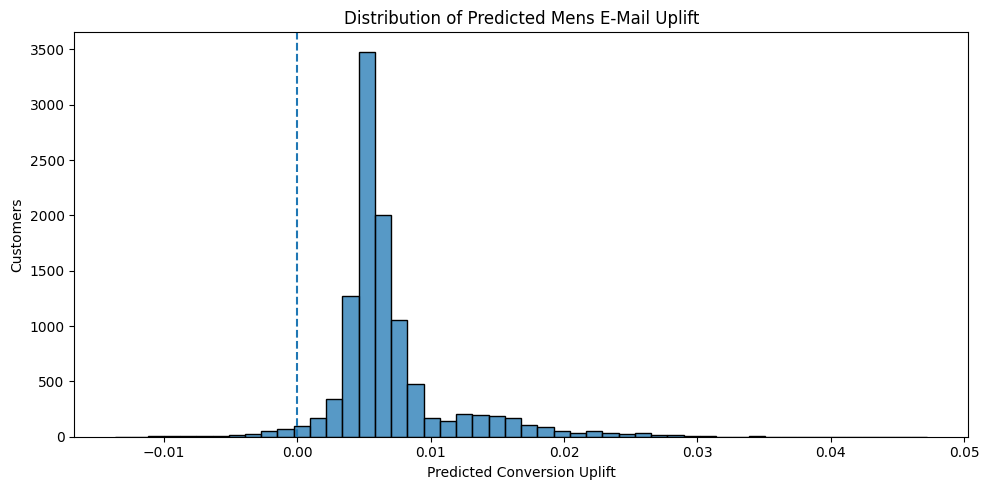

In [113]:
# Visualize predicted customer-level uplift
plt.figure(figsize=(10, 5))

sns.histplot(
    data=uplift_results,
    x="predicted_uplift",
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Predicted Mens E-Mail Uplift")
plt.xlabel("Predicted Conversion Uplift")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

### Chart Interpretation

The distribution shows that predicted treatment effects differ across customers.

Some customers have:

- positive predicted uplift
- near-zero predicted uplift
- potentially negative predicted uplift

This is the key insight behind uplift modeling.

The average A/B test tells us whether a campaign works overall.

The uplift model attempts to identify which specific customers are most likely to change behavior because of the campaign.

### Business Implication

Customers with the highest positive predicted uplift should be prioritized for targeting.

Customers with near-zero uplift may not need the campaign.

Customers with negative predicted uplift may potentially respond worse after treatment and should be treated cautiously.

The targeting strategy becomes:

> Rank customers by predicted uplift → contact highest-value customers first

In [114]:
# Rank customers from highest to lowest predicted uplift
uplift_results = uplift_results.sort_values(
    "predicted_uplift",
    ascending=False
).copy()

# Divide customers into 10 equally sized groups
uplift_results["uplift_decile"] = pd.qcut(
    uplift_results["predicted_uplift"].rank(
        method="first",
        ascending=False
    ),
    q=10,
    labels=False
) + 1

uplift_results.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,actual_conversion,actual_treatment,p_conversion_treated,p_conversion_control,predicted_uplift,uplift_decile
46493,1,"7) $1,000 +","2,895.1100",1,1,Urban,1,Multichannel,0,1,0.0808,0.0335,0.0472,1
15808,6,"7) $1,000 +","2,583.8400",1,1,Urban,1,Multichannel,0,1,0.0598,0.0158,0.0440,1
43060,1,"7) $1,000 +","3,003.4800",1,1,Urban,1,Phone,0,0,0.0691,0.0312,0.0379,1
53806,5,"7) $1,000 +","1,667.2700",1,1,Suburban,1,Multichannel,0,1,0.0436,0.0087,0.0349,1
5578,1,"7) $1,000 +","2,728.6900",1,1,Urban,1,Phone,0,1,0.0616,0.0267,0.0349,1


Evaluate observed treatment effect by decile

In [115]:
# Create separate observed outcomes for treated and control customers
uplift_results["treated_conversion"] = np.where(
    uplift_results["actual_treatment"] == 1,
    uplift_results["actual_conversion"],
    np.nan
)

uplift_results["control_conversion"] = np.where(
    uplift_results["actual_treatment"] == 0,
    uplift_results["actual_conversion"],
    np.nan
)

# Summarize observed treatment effect by predicted uplift decile
decile_summary = (
    uplift_results
    .groupby("uplift_decile")
    .agg(
        customers=("actual_conversion", "size"),
        treated_customers=("actual_treatment", "sum"),
        treated_conversion_rate=("treated_conversion", "mean"),
        control_conversion_rate=("control_conversion", "mean"),
        avg_predicted_uplift=("predicted_uplift", "mean")
    )
    .reset_index()
)

# Calculate observed uplift
decile_summary["observed_uplift"] = (
    decile_summary["treated_conversion_rate"]
    - decile_summary["control_conversion_rate"]
)

decile_summary

,uplift_decile,customers,treated_customers,treated_conversion_rate,control_conversion_rate,avg_predicted_uplift,observed_uplift
0,1,1066,524,0.0248,0.0111,0.0180,0.0137
1,2,1065,520,0.0154,0.0073,0.0099,0.0080
2,3,1065,562,0.0107,0.0099,0.0074,0.0007
3,4,1066,516,0.0039,0.0036,0.0065,0.0002
4,5,1065,518,0.0116,0.0018,0.0060,0.0098
5,6,1065,536,0.0168,0.0038,0.0056,0.0130
6,7,1066,542,0.0037,0.0019,0.0052,0.0018
7,8,1065,544,0.0037,0.0038,0.0048,-0.0002
8,9,1065,519,0.0058,0.0055,0.0043,0.0003
9,10,1066,546,0.0293,0.0096,0.0016,0.0197


Visualize observed uplift by decile

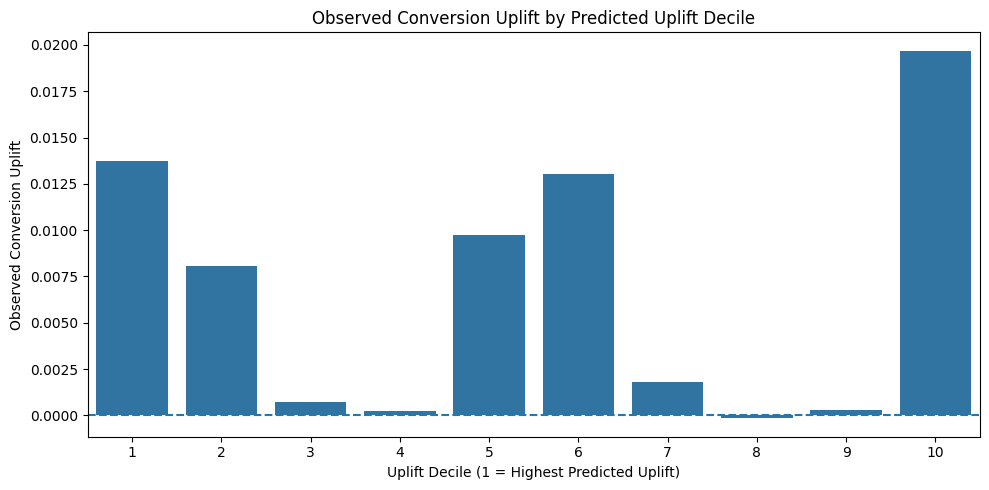

In [116]:
# Visualize observed treatment effect by predicted uplift decile
plt.figure(figsize=(10, 5))

sns.barplot(
    data=decile_summary,
    x="uplift_decile",
    y="observed_uplift",
    errorbar=None
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Observed Conversion Uplift by Predicted Uplift Decile")
plt.xlabel("Uplift Decile (1 = Highest Predicted Uplift)")
plt.ylabel("Observed Conversion Uplift")
plt.tight_layout()
plt.show()

### Decile Analysis Interpretation

The model successfully generates variation in predicted customer-level uplift, but the observed treatment effects do not decrease consistently from the highest-ranked to the lowest-ranked deciles.

Several higher-ranked deciles show positive observed uplift. However, the relationship is not monotonic.

Most importantly, the lowest predicted uplift decile still shows strong positive observed uplift, despite receiving a strongly negative average predicted uplift score.

This indicates that the current Logistic Regression T-Learner does not reliably rank customers by true treatment responsiveness.

### Business Implication

The model should not yet be deployed as a customer suppression or targeting system.

Using the current ranking could incorrectly exclude customers who may still benefit significantly from treatment.

The correct conclusion is:

> The initial T-Learner provides evidence that treatment effects may vary across customers, but the current model does not yet produce a sufficiently stable uplift ranking for production targeting.

The next step is to compare stronger nonlinear learners and use uplift-specific evaluation metrics.

In [117]:
# Mark top 20% of customers by predicted uplift
uplift_results["target_top_20_pct"] = (
    uplift_results["uplift_decile"] <= 2
)

# Check targeting counts
uplift_results["target_top_20_pct"].value_counts()

target_top_20_pct
False    8523
True     2131
Name: count, dtype: int64

Compare top 20% vs all customers

In [118]:
# Top 20% customers
top_20 = uplift_results[
    uplift_results["target_top_20_pct"]
].copy()

# Observed treatment effect among top 20%
top_20_treated_rate = (
    top_20.loc[
        top_20["actual_treatment"] == 1,
        "actual_conversion"
    ].mean()
)

top_20_control_rate = (
    top_20.loc[
        top_20["actual_treatment"] == 0,
        "actual_conversion"
    ].mean()
)

top_20_observed_uplift = (
    top_20_treated_rate
    - top_20_control_rate
)

print(f"Top 20% treated conversion rate: {top_20_treated_rate:.4%}")
print(f"Top 20% control conversion rate: {top_20_control_rate:.4%}")
print(f"Top 20% observed uplift: {top_20_observed_uplift:.4%}")

Top 20% treated conversion rate: 2.0115%
Top 20% control conversion rate: 0.9200%
Top 20% observed uplift: 1.0915%


### Top-20% Targeting Interpretation

The top 20% of customers ranked by predicted uplift are compared with the full test population to determine whether the model concentrates stronger treatment effects among high-ranked customers.

A stronger observed uplift in the top 20% suggests that the model is identifying a subset of customers who may be more responsive to treatment.

However, this result must be interpreted alongside the decile analysis. Strong top-of-ranking performance does not automatically imply that the full customer ranking is stable.

### Business Implication

The Logistic Regression T-Learner may provide useful treatment-effect concentration at the top of the ranking, but deployment should depend on whether an advanced challenger can improve targeting performance without sacrificing calibration.

Compare with full population

In [119]:
# Overall observed treatment effect
overall_treated_rate = (
    uplift_results.loc[
        uplift_results["actual_treatment"] == 1,
        "actual_conversion"
    ].mean()
)

overall_control_rate = (
    uplift_results.loc[
        uplift_results["actual_treatment"] == 0,
        "actual_conversion"
    ].mean()
)

overall_observed_uplift = (
    overall_treated_rate
    - overall_control_rate
)

print(f"Overall treated conversion rate: {overall_treated_rate:.4%}")
print(f"Overall control conversion rate: {overall_control_rate:.4%}")
print(f"Overall observed uplift: {overall_observed_uplift:.4%}")

Overall treated conversion rate: 1.2577%
Overall control conversion rate: 0.5819%
Overall observed uplift: 0.6758%


Final comparison table

In [120]:
# Compare broad targeting with top-20% targeting
targeting_comparison = pd.DataFrame({
    "strategy": [
        "All Customers",
        "Top 20% Predicted Uplift"
    ],
    "treated_conversion_rate": [
        overall_treated_rate,
        top_20_treated_rate
    ],
    "control_conversion_rate": [
        overall_control_rate,
        top_20_control_rate
    ],
    "observed_uplift": [
        overall_observed_uplift,
        top_20_observed_uplift
    ]
})

targeting_comparison

,strategy,treated_conversion_rate,control_conversion_rate,observed_uplift
0,All Customers,0.0126,0.0058,0.0068
1,Top 20% Predicted Uplift,0.0201,0.0092,0.0109


In [122]:
# Measure how much stronger the top-20% uplift is
# compared with broad targeting
top_20_lift_improvement = (
    top_20_observed_uplift
    - overall_observed_uplift
) / overall_observed_uplift

print(
    f"Top-20% uplift concentration improvement: "
    f"{top_20_lift_improvement:.2%}"
)

Top-20% uplift concentration improvement: 61.52%


# Part 2: LightGBM Challenger

## Why Add a Nonlinear Model?

The Logistic Regression T-Learner provides a useful baseline because it is simple, transparent, and easy to debug.

However, Logistic Regression mainly learns linear relationships.

Customer treatment response may depend on more complex patterns such as:

- recency interacting with purchase history
- customer channel interacting with prior behavior
- nonlinear thresholds in historical spending
- different response patterns across customer segments

To test whether these relationships improve targeting, we add one advanced challenger:

> LightGBM T-Learner

For a fair comparison, we reuse:

- the same customer features
- the same train/test split
- the same treatment and control groups
- the same test customers

We do not repeat data preparation or experiment analysis.

### Baseline Targeting Result

This comparison measures whether ranking customers by predicted uplift concentrates stronger treatment effects at the top of the customer list.

A positive concentration improvement means the top-ranked customers produced stronger observed uplift than the full test population.

This provides the baseline result that the LightGBM challenger must beat.

The next question is:

> Can a nonlinear model improve customer targeting beyond this simple Logistic Regression baseline?

In [124]:
# LightGBM treatment model
# Estimates conversion probability if a customer
# receives the Mens E-Mail campaign
lgbm_treatment_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.05,
                num_leaves=15,
                random_state=42,
                verbosity=-1
            )
        )
    ]
)

In [125]:
# LightGBM control model
# Estimates conversion probability if a customer
# receives no email
lgbm_control_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LGBMClassifier(
                n_estimators=300,
                learning_rate=0.05,
                num_leaves=15,
                random_state=42,
                verbosity=-1
            )
        )
    ]
)

In [126]:
# Train the treatment model on customers
# who actually received Mens E-Mail
lgbm_treatment_model.fit(
    X_train_treated,
    y_train_treated
)

# Train the control model on customers
# who actually received No E-Mail
lgbm_control_model.fit(
    X_train_control,
    y_train_control
)

print("LightGBM treatment and control models trained successfully.")

LightGBM treatment and control models trained successfully.


In [127]:
# Predicted conversion probability under treatment
lgbm_p_treatment = (
    lgbm_treatment_model
    .predict_proba(X_test)[:, 1]
)

# Predicted conversion probability under control
lgbm_p_control = (
    lgbm_control_model
    .predict_proba(X_test)[:, 1]
)

print("Treatment predictions:")
print(lgbm_p_treatment[:5])

print("\nControl predictions:")
print(lgbm_p_control[:5])

Treatment predictions:
[0.00509667 0.01654062 0.00092527 0.00742876 0.0077276 ]

Control predictions:
[2.71141826e-05 1.54132175e-02 8.57574467e-05 1.10941162e-02
 8.22420810e-03]


c:\Users\tevin\OneDrive\Desktop\Product_ml\ab_testing\hillstrom-ab-testing\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\tevin\OneDrive\Desktop\Product_ml\ab_testing\hillstrom-ab-testing\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [128]:
# Estimate customer-level treatment effect
lgbm_predicted_uplift = (
    lgbm_p_treatment
    - lgbm_p_control
)

# Preview uplift scores
lgbm_predicted_uplift[:10]

array([ 0.00506955,  0.0011274 ,  0.00083952, -0.00366536, -0.00049661,
        0.00028562,  0.03347566,  0.00097552,  0.00883713,  0.0071836 ])

In [129]:
# Compare LightGBM predictions with
# experimentally observed conversion rates
lgbm_probability_check = pd.DataFrame({
    "metric": [
        "Observed treated conversion rate",
        "Average predicted treated probability",
        "Observed control conversion rate",
        "Average predicted control probability"
    ],
    "value": [
        y_test[treatment_test == 1].mean(),
        lgbm_p_treatment.mean(),
        y_test[treatment_test == 0].mean(),
        lgbm_p_control.mean()
    ]
})

lgbm_probability_check

,metric,value
0,Observed treated conversion rate,0.0126
1,Average predicted treated probability,0.0121
2,Observed control conversion rate,0.0058
3,Average predicted control probability,0.0049


### LightGBM Probability Sanity Check

Before using the LightGBM uplift scores for customer targeting, we compare average predicted probabilities with observed experimental conversion rates.

The purpose is to verify that the advanced model produces probabilities on a realistic scale.

A more complex model is not useful if its potential-outcome probabilities are badly miscalibrated.

In [130]:
# Average treatment effect predicted by LightGBM
lgbm_predicted_ate = (
    lgbm_predicted_uplift.mean()
)

# Difference from the experimentally observed ATE
lgbm_ate_calibration_gap = (
    lgbm_predicted_ate
    - observed_ate
)

print(
    f"LightGBM predicted ATE: "
    f"{lgbm_predicted_ate:.4%}"
)

print(
    f"Observed ATE: "
    f"{observed_ate:.4%}"
)

print(
    f"ATE calibration gap: "
    f"{lgbm_ate_calibration_gap:.4%}"
)

LightGBM predicted ATE: 0.7216%
Observed ATE: 0.6758%
ATE calibration gap: 0.0458%


In [131]:
# Store both model scores for the same test customers
model_comparison_results = pd.DataFrame({
    "actual_conversion": y_test.values,
    "actual_treatment": treatment_test.values,
    "logreg_uplift": predicted_uplift,
    "lgbm_uplift": lgbm_predicted_uplift
})

model_comparison_results.head()

,actual_conversion,actual_treatment,logreg_uplift,lgbm_uplift
0,0,1,0.0057,0.0051
1,0,0,0.0173,0.0011
2,0,1,0.0042,0.0008
3,0,1,0.0051,-0.0037
4,0,0,-0.0006,-0.0005


In [132]:
def evaluate_top_fraction(
    results,
    uplift_column,
    top_fraction=0.20
):
    """
    Evaluate observed treatment uplift among the
    highest-ranked customers.

    Parameters
    ----------
    results : pd.DataFrame
        Test-set results containing actual treatment,
        actual conversion, and uplift scores.

    uplift_column : str
        Column containing predicted uplift scores.

    top_fraction : float
        Fraction of highest-ranked customers to evaluate.

    Returns
    -------
    dict
        Targeting performance metrics.
    """

    # Rank customers from highest to lowest predicted uplift
    ranked = results.sort_values(
        uplift_column,
        ascending=False
    ).copy()

    # Calculate how many customers belong to the target group
    n_target = int(
        len(ranked) * top_fraction
    )

    # Keep only the highest-ranked customers
    targeted = ranked.head(
        n_target
    )

    # Observed conversion rate among treated customers
    treated_rate = targeted.loc[
        targeted["actual_treatment"] == 1,
        "actual_conversion"
    ].mean()

    # Observed conversion rate among control customers
    control_rate = targeted.loc[
        targeted["actual_treatment"] == 0,
        "actual_conversion"
    ].mean()

    # Observed treatment effect
    observed_uplift = (
        treated_rate
        - control_rate
    )

    return {
        "customers_targeted": len(targeted),
        "treated_conversion_rate": treated_rate,
        "control_conversion_rate": control_rate,
        "observed_uplift": observed_uplift
    }

In [133]:
# Evaluate top 20% ranked by
# Logistic Regression predicted uplift
logreg_top_20 = evaluate_top_fraction(
    results=model_comparison_results,
    uplift_column="logreg_uplift",
    top_fraction=0.20
)

logreg_top_20

{'customers_targeted': 2130,
 'treated_conversion_rate': np.float64(0.020114942528735632),
 'control_conversion_rate': np.float64(0.009208103130755065),
 'observed_uplift': np.float64(0.010906839397980567)}

In [134]:
# Evaluate top 20% ranked by
# LightGBM predicted uplift
lgbm_top_20 = evaluate_top_fraction(
    results=model_comparison_results,
    uplift_column="lgbm_uplift",
    top_fraction=0.20
)

lgbm_top_20

{'customers_targeted': 2130,
 'treated_conversion_rate': np.float64(0.022325581395348838),
 'control_conversion_rate': np.float64(0.006635071090047393),
 'observed_uplift': np.float64(0.015690510305301445)}

# Part 3: Model Comparison

The final step compares the transparent Logistic Regression baseline with the nonlinear LightGBM challenger.

Both models are evaluated on:

- the same experiment
- the same train/test split
- the same customer features
- the same test customers
- the same top-20% targeting rule

The preferred model should provide strong targeting performance without producing unrealistic treatment-effect estimates.

In [135]:
# Compare the baseline and advanced challenger
model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression T-Learner",
        "LightGBM T-Learner"
    ],
    "predicted_ate": [
        predicted_ate,
        lgbm_predicted_ate
    ],
    "ate_calibration_gap": [
        predicted_ate - observed_ate,
        lgbm_predicted_ate - observed_ate
    ],
    "top_20_observed_uplift": [
        logreg_top_20["observed_uplift"],
        lgbm_top_20["observed_uplift"]
    ]
})

model_comparison

,model,predicted_ate,ate_calibration_gap,top_20_observed_uplift
0,Logistic Regression T-Learner,0.0069,0.0002,0.0109
1,LightGBM T-Learner,0.0072,0.0005,0.0157


In [136]:
# Create presentation-friendly percentage values
model_comparison_display = (
    model_comparison.copy()
)

percentage_columns = [
    "predicted_ate",
    "ate_calibration_gap",
    "top_20_observed_uplift"
]

for column in percentage_columns:
    model_comparison_display[column] = (
        model_comparison_display[column]
        * 100
    ).round(3)

model_comparison_display

,model,predicted_ate,ate_calibration_gap,top_20_observed_uplift
0,Logistic Regression T-Learner,0.6940,0.0180,1.0910
1,LightGBM T-Learner,0.7220,0.0460,1.5690


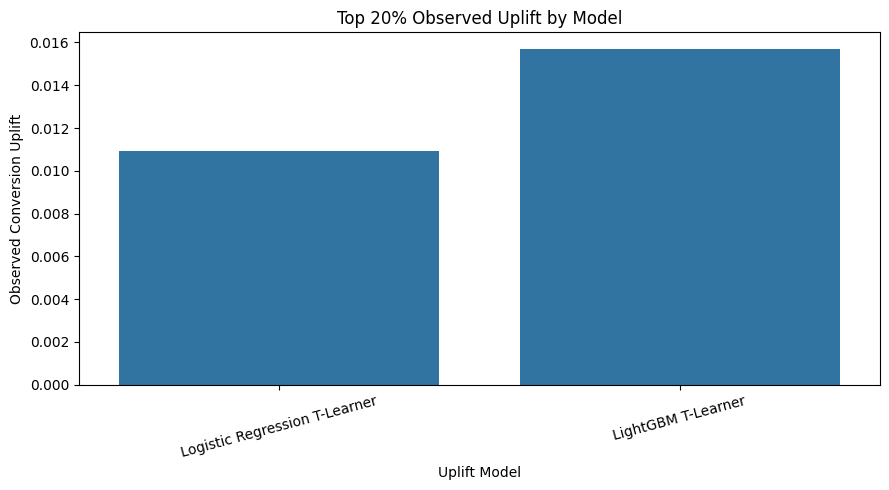

In [137]:
# Compare observed uplift among the
# top 20% of customers ranked by each model
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_comparison,
    x="model",
    y="top_20_observed_uplift",
    errorbar=None
)

plt.title(
    "Top 20% Observed Uplift by Model"
)
plt.xlabel(
    "Uplift Model"
)
plt.ylabel(
    "Observed Conversion Uplift"
)
plt.xticks(
    rotation=15
)
plt.tight_layout()
plt.show()

### Model Comparison Interpretation

The Logistic Regression T-Learner provides a simple and transparent baseline.

The LightGBM T-Learner tests whether nonlinear customer relationships improve treatment targeting.

The preferred model should not be selected simply because it is more advanced.

The decision should consider:

1. How closely predicted ATE matches the experimental ATE
2. Whether predicted probabilities remain realistic
3. Whether the top 20% of ranked customers show stronger observed uplift
4. Whether the improvement is meaningful enough to justify additional complexity

### Business Decision Rule

If LightGBM produces meaningfully stronger targeting while maintaining reasonable calibration, it should be preferred.

If LightGBM does not clearly outperform Logistic Regression, the simpler baseline should remain the preferred model.

# Final Customer Targeting Conclusion

The previous statistical analysis established that the Mens E-Mail campaign produced the strongest overall treatment effect and business value.

This notebook continued from that result by asking:

> Which customers should receive the campaign?

## Models Compared

Two T-Learner approaches were evaluated:

1. Logistic Regression T-Learner
2. LightGBM T-Learner

The Logistic Regression model served as a simple and transparent baseline.

The LightGBM model tested whether nonlinear customer relationships improved treatment targeting.

## Evaluation Strategy

The models were compared using:

- predicted average treatment effect
- observed experimental treatment effect
- ATE calibration gap
- probability sanity checks
- top-20% observed uplift

## Final Model Decision

The preferred model should be selected from the comparison table above.

The winning model is the one that provides the strongest balance of:

- realistic treatment-effect estimates
- small calibration error
- stronger high-value targeting
- manageable model complexity

## Business Recommendation

The company should continue using the Mens E-Mail campaign, but customer-level targeting may improve efficiency beyond broad campaign delivery.

The proposed workflow is:

Mens E-Mail campaign  
→ rank eligible customers by predicted uplift  
→ prioritize highest-value customers  
→ measure incremental conversion  
→ monitor targeting performance over time

## Important Limitation

Customer-level treatment effects are estimated rather than directly observed.

For each customer, only one outcome is observed:

- treated
- or untreated

Therefore, uplift predictions should support controlled targeting experiments rather than be treated as guaranteed individual causal effects.